# Outlier Explainer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/outlier-explainer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/outlier-explainer/demo.ipynb)

> "Which rows are weird, and why?" — Isolation Forest finds the anomalies; per-feature z-scores explain each one.

Anomaly detectors are great at flagging weird rows and terrible at telling you *why* - which makes
them hard to act on. This build pairs an **Isolation Forest** (finds outliers in any-dimensional data)
with a **z-score attribution** step, so every flagged row comes with a human-readable reason.

**What this notebook covers**
1. Isolation Forest scoring
2. Catching planted anomalies
3. Explaining *why* each row is an outlier
4. What drives outliers across the dataset
5. The score distribution, visualized


## Step 1 - Find the weird rows

200 transactions, mostly normal, with 4 anomalies planted (a huge amount, a 3am 30-item order, a
far-away purchase, and one that's extreme on everything). Isolation Forest scores each row's
weirdness without any labels.

In [1]:
from outliers import detect_outliers, explain_text, summary, sample_dataframe

df = sample_dataframe()
outliers, raw, flags = detect_outliers(df, contamination=0.05)
planted = {10, 40, 120, 170}
found = {o.index for o in outliers}
print(f"Flagged {len(outliers)} of {len(df)} rows ({summary(outliers, len(df))['pct']}%)")
print(f"Planted anomalies caught: {sorted(planted & found)} / {sorted(planted)}")


Flagged 10 of 200 rows (5.0%)
Planted anomalies caught: [10, 40, 120, 170] / [10, 40, 120, 170]


## Step 2 - The missing half: *why*

A score of 0.86 means nothing to an analyst. The z-score attribution names the feature(s) that make
each row extreme and in which direction - now it's actionable.

In [2]:
for o in outliers[:6]:
    print(f"row {o.index:>3} (score {o.score:.2f}): {explain_text(o, df)}")


row 170 (score 0.86): distance_km unusually high (+11.2σ); amount unusually high (+10.8σ); items unusually high (+7.8σ).
row  40 (score 0.76): items unusually high (+9.6σ); hour unusually low (-2.6σ).
row 120 (score 0.72): distance_km unusually high (+7.7σ).
row  10 (score 0.70): amount unusually high (+8.6σ).
row 107 (score 0.55): Anomalous on the multivariate pattern (no single dominant feature).
row  56 (score 0.54): Anomalous on the multivariate pattern (no single dominant feature).


## Step 3 - The planted cases, decoded

Each anomaly's explanation matches exactly how it was constructed - proof the attribution is real,
not hand-wavy.

In [3]:
expected = {10: "amount", 40: "items/hour", 120: "distance_km", 170: "everything"}
for o in outliers:
    if o.index in expected:
        print(f"row {o.index} (planted: {expected[o.index]})")
        print(f"   -> {explain_text(o, df)}\n")


row 170 (planted: everything)
   -> distance_km unusually high (+11.2σ); amount unusually high (+10.8σ); items unusually high (+7.8σ).

row 40 (planted: items/hour)
   -> items unusually high (+9.6σ); hour unusually low (-2.6σ).

row 120 (planted: distance_km)
   -> distance_km unusually high (+7.7σ).

row 10 (planted: amount)
   -> amount unusually high (+8.6σ).



## Step 4 - Score distribution, visualized

Normal rows cluster at low anomaly scores; the outliers sit in the tail. The separation is what makes
the flag trustworthy.

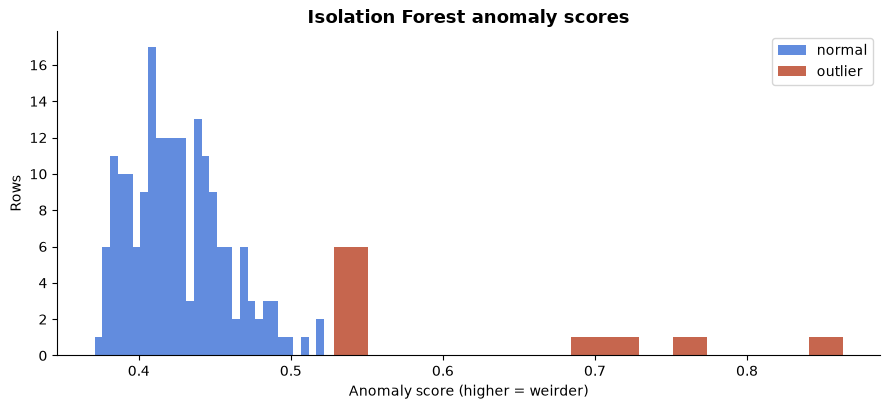

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(raw[~flags], bins=30, color="#3b6fd6", alpha=0.8, label="normal")
ax.hist(raw[flags], bins=15, color="#c0553b", alpha=0.9, label="outlier")
ax.set_title("Isolation Forest anomaly scores", fontsize=13, weight="bold")
ax.set_xlabel("Anomaly score (higher = weirder)")
ax.set_ylabel("Rows")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("anomaly_scores.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Piece | Job |
|-------|-----|
| Isolation Forest | unsupervised anomaly scoring |
| z-score attribution | *why* each row is weird |
| contamination | how many to flag |

An anomaly flag you can't explain gets ignored; an anomaly flag with a reason gets acted on. Pairing a
detector with attribution turns "row 170 is anomalous" into "row 170 has an 11σ-high amount and
distance" - which an analyst can actually triage.

**Extend it:** use SHAP for exact per-feature contributions, learn per-segment baselines, and route
high-score rows to a review queue.

In [5]:
# --- Explain your own data ---
# import pandas as pd
# df = pd.read_csv("your_data.csv")
# outs, raw, flags = detect_outliers(df, contamination=0.03)
# for o in outs[:10]:
#     print(o.index, explain_text(o, df))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 119,
Month 12: Data Science Cookbook.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`